# CONDOR-label training with FlexDC data and W&B

This notebook keeps the released CONDOR architecture, three output meanings, loss, optimizer, and 70/30 split. The only data change is that the inputs and raw measurements come from the FlexDC pilot results CSV.

Before running, place these files in the Colab `/content` folder using the Files panel:

- `data_center_model.py`
- `am_condor_flexdc_training_utilities.py`
- `traditional_iso16_fullpilot_AQA_combined_grid_search_results.csv`


In [ ]:
#Upload these to get started
#data_center_model.py
#am_condor_flexdc_training_utilities.py
#am_condor_flexdc_inference_colab.py
#traditional_iso16_fullpilot_AQA_combined_grid_search_results.csv
#traditional_iso16_fullpilot_AQA_combined_grid_search_diagnostics.csv

In [5]:
!pip -q install wandb

In [8]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: amenon06 (amenon06-boston-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Optional upload helper. Run this only if the files are not already in /content.
# from google.colab import files
# files.upload()


In [9]:
import sys
import random
from pathlib import Path

# Ensure the /content directory is in the path for local imports
if "/content" not in sys.path:
    sys.path.append("/content")

import matplotlib.pyplot as plt
import numpy as np
import torch
import wandb

from data_center_model import DataCenterModel
from am_condor_flexdc_training_utilities import train_model, evaluate_model

SEED = 0
DATA_FILE = "/content/traditional_iso16_fullpilot_AQA_combined_grid_search_results.csv"
MODEL_FILE = "/content/am_condor_flexdc_labels_v1_state_dict.pt"

for required_file in [
    "/content/data_center_model.py",
    "/content/am_condor_flexdc_training_utilities.py",
    DATA_FILE,
]:
    if not Path(required_file).exists():
        raise FileNotFoundError(f"Upload this file to /content first: {required_file}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

wandb.login()
run = wandb.init(
    entity="amenon06-boston-university",
    project="flexdc-condor",
    name="condor-labels-flexdc-data-v1",
    config={
        "architecture": "released CONDOR DataCenterModel",
        "dataset": "FlexDC traditional-ISO pilot",
        "labels": ["cost_power", "cost_error", "cost_qos"],
        "cost_power": "0.0003 * (P_watts - R_watts)",
        "cost_error": "mean absolute tracking error in kW",
        "cost_qos": "0.8 * sum SoftPlus(60 * (delay_probability - 0.1))",
        "epochs": 150,
        "learning_rate": 1e-4,
        "batch_size": 512,
        "split": "deterministic 70/30, seed 0",
        "optimizer": "AdamW",
        "loss": "MSE",
    },
)

In [10]:
# Makes the unchanged CONDOR model architecture.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")

sim_model = DataCenterModel()
sim_model.to(device)
sim_model.train()

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda:0
GPU: Tesla T4


In [11]:
# Trains the original CONDOR-style components using FlexDC inputs.
# [cost_power, cost_error, cost_qos]
sim_model, train_loss_record, heldout_loss_record = train_model(
    sim_model,
    epochs=150,
    lr=1e-4,
    batch_size=512,
    verbose=True,
    cross_validate=True,
    data_file_path=DATA_FILE,
    wandb_run=run,
)


Epoch 0 Train Loss: 138.2618895522109 Test Loss: 120.94994433720906
Epoch 1 Train Loss: 118.37062787580061 Test Loss: 120.2742091814677
Epoch 2 Train Loss: 118.19733442701735 Test Loss: 119.90436538060506
Epoch 3 Train Loss: 118.0151940423089 Test Loss: 120.12933079401652
Epoch 4 Train Loss: 117.71835801408098 Test Loss: 119.23797448476155
Epoch 5 Train Loss: 116.59554606944592 Test Loss: 118.26832993825276
Epoch 6 Train Loss: 113.80372722728832 Test Loss: 111.83166042963664
Epoch 7 Train Loss: 105.95572566126918 Test Loss: 97.55152750015259
Epoch 8 Train Loss: 89.6568047463357 Test Loss: 78.97752539316814
Epoch 9 Train Loss: 72.2704472241101 Test Loss: 65.61204854647319
Epoch 10 Train Loss: 58.815862122956695 Test Loss: 51.59442941347758
Epoch 11 Train Loss: 48.304027213706625 Test Loss: 40.917397816975914
Epoch 12 Train Loss: 40.8890249235136 Test Loss: 42.109011809031166
Epoch 13 Train Loss: 35.73929195575886 Test Loss: 32.3244891166687
Epoch 14 Train Loss: 31.233740041921806 Test L

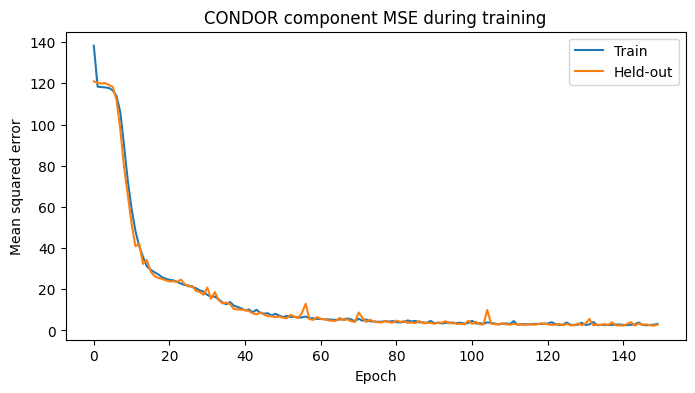

In [12]:
fig = plt.figure(figsize=(8, 4))
plt.title("CONDOR component MSE during training")
plt.plot(train_loss_record, label="Train")
plt.plot(heldout_loss_record, label="Held-out")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()


In [13]:
torch.save(sim_model.state_dict(), MODEL_FILE)
print(f"Saved model state dict to: {MODEL_FILE}")


Saved model state dict to: /content/am_condor_flexdc_labels_v1_state_dict.pt


In [14]:
loaded_model = DataCenterModel()
loaded_model.load_state_dict(torch.load(MODEL_FILE, map_location=device))
loaded_model.to(device)
loaded_model.eval()

y_true_train, y_pred_train, y_true_test, y_pred_test = evaluate_model(
    loaded_model,
    cross_validate=True,
    data_file_path=DATA_FILE,
)


MSE  || Train: 2.765925168991089 | Test: 2.8732855319976807
MAPE || Train: 30802094063616.0 | Test: 31384213127168.0
Total MSE  || Train: 11.678582191467285 | Test: 12.29997444152832
Total MAPE || Train: 0.13982470333576202 | Test: 0.14317922294139862


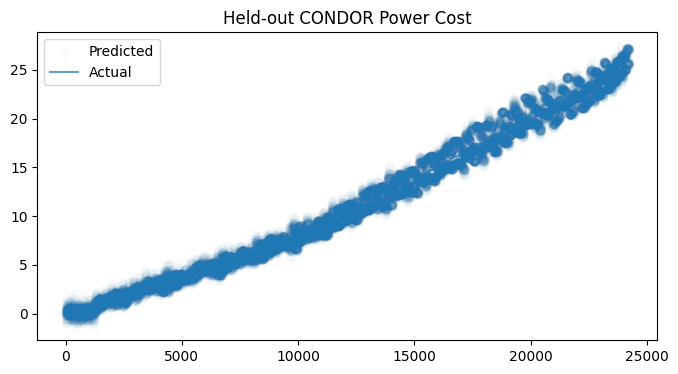

In [15]:
plt.figure(figsize=(8, 4))
plt.title("Held-out CONDOR Power Cost")
ind = np.argsort(y_true_test[:, 0])
plt.scatter(range(len(ind)), y_pred_test[ind, 0], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), y_true_test[ind, 0], alpha=0.7, label="Actual")
plt.legend()
plt.show()


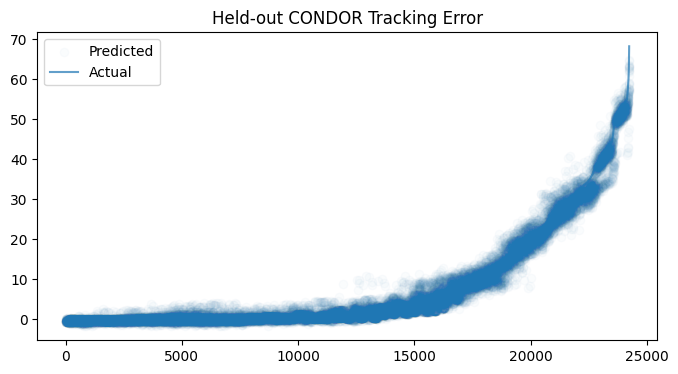

In [16]:
plt.figure(figsize=(8, 4))
plt.title("Held-out CONDOR Tracking Error")
ind = np.argsort(y_true_test[:, 1])
plt.scatter(range(len(ind)), y_pred_test[ind, 1], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), y_true_test[ind, 1], alpha=0.7, label="Actual")
plt.legend()
plt.show()


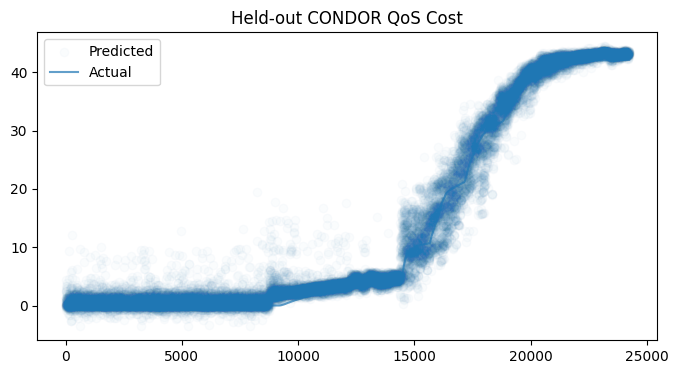

In [17]:
plt.figure(figsize=(8, 4))
plt.title("Held-out CONDOR QoS Cost")
ind = np.argsort(y_true_test[:, 2])
plt.scatter(range(len(ind)), y_pred_test[ind, 2], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), y_true_test[ind, 2], alpha=0.7, label="Actual")
plt.legend()
plt.show()


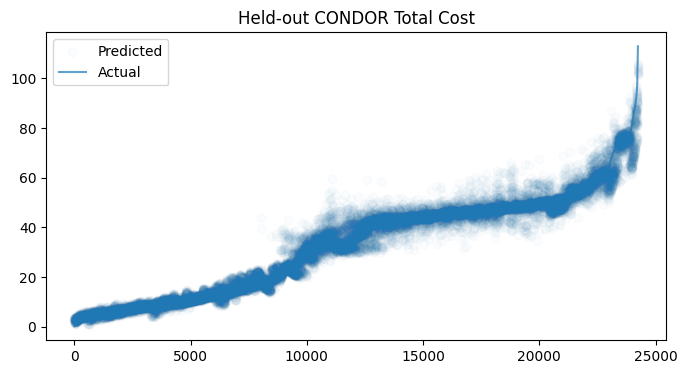

In [18]:
actual_total = y_true_test.sum(axis=1)
predicted_total = y_pred_test.sum(axis=1)

plt.figure(figsize=(8, 4))
plt.title("Held-out CONDOR Total Cost")
ind = np.argsort(actual_total)
plt.scatter(range(len(ind)), predicted_total[ind], alpha=0.02, label="Predicted")
plt.plot(range(len(ind)), actual_total[ind], alpha=0.7, label="Actual")
plt.legend()
plt.show()


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

names = ["cost_power", "cost_error", "cost_qos"]
final_metrics = {}

for i, name in enumerate(names):
    actual = y_true_test[:, i]
    predicted = y_pred_test[:, i]
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    r2 = r2_score(actual, predicted)

    print(name)
    print("  MAE: ", mae)
    print("  RMSE:", rmse)
    print("  R²:  ", r2)

    final_metrics[f"heldout/{name}_mae"] = mae
    final_metrics[f"heldout/{name}_rmse"] = rmse
    final_metrics[f"heldout/{name}_r2"] = r2

actual_total = y_true_test.sum(axis=1)
predicted_total = y_pred_test.sum(axis=1)

print("total_cost")
print("  MAE: ", mean_absolute_error(actual_total, predicted_total))
print("  RMSE:", mean_squared_error(actual_total, predicted_total) ** 0.5)
print("  R²:  ", r2_score(actual_total, predicted_total))

final_metrics["heldout/total_cost_mae"] = mean_absolute_error(actual_total, predicted_total)
final_metrics["heldout/total_cost_rmse"] = mean_squared_error(actual_total, predicted_total) ** 0.5
final_metrics["heldout/total_cost_r2"] = r2_score(actual_total, predicted_total)
run.log(final_metrics)


cost_power
  MAE:  0.6906642913818359
  RMSE: 0.8648325243103318
  R²:   0.9875484108924866
cost_error
  MAE:  1.1622893810272217
  RMSE: 1.800364878547566
  R²:   0.9825986623764038
cost_qos
  MAE:  1.398963451385498
  RMSE: 2.1518900924538924
  R²:   0.9833421111106873
total_cost
  MAE:  2.323990821838379
  RMSE: 3.50713193956662
  R²:   0.9711887240409851


In [20]:
run.finish()
print("W&B run finished.")


heldout/cost_error_mae,▁
heldout/cost_error_r2,▁
heldout/cost_error_rmse,▁
heldout/cost_power_mae,▁
heldout/cost_power_r2,▁
heldout/cost_power_rmse,▁
heldout/cost_qos_mae,▁
heldout/cost_qos_r2,▁
heldout/cost_qos_rmse,▁
heldout/total_cost_mae,▁
+4,...


W&B run finished.


In [38]:
#Add gradient descent wandb
!python /content/am_condor_flexdc_inference_colab.py \
  --results-csv /content/traditional_iso16_fullpilot_AQA_combined_grid_search_results.csv \
  --diagnostics-csv /content/traditional_iso16_fullpilot_AQA_combined_grid_search_diagnostics.csv \
  --model-file /content/am_condor_flexdc_labels_v1_state_dict.pt \
  --out-dir /content/condor_inference_w1_n1000_u060 \
  --workload W2-short-qos2-2.5-2.5-3 \
  --server-count 1000 \
  --utilization 0.80 \
  --weight-sample-id 0 \
  --iterations 1000 \
  --lr 0.01 \
  --power-weight 0.05 \
  --error-weight 0.7 \
  --qos-weight 2.0

Device: cuda:0
Cost weights [power, error, QoS]: [0.05, 0.7, 2.0]
Starting P/R: 0.4858666666666666 0.2225185185185185
Optimized P/R: 0.7109411358833313 0.009999999776482582
Optimized weights: [0.250244140625, 0.258474737405777, 0.24619720876216888, 0.24508386850357056]
Predicted weighted objective: 19.589284896850586

Saved:
/content/condor_inference_w1_n1000_u060/optimization_trajectory.csv
/content/condor_inference_w1_n1000_u060/optimization_comparison_before_validation.csv
/content/condor_inference_w1_n1000_u060/optimized_candidate.json


In [22]:
import json
import pandas as pd

candidate = json.load(
    open("/content/condor_inference_w1_n1000_u060/optimized_candidate.json")
)

display(candidate)
display(
    pd.read_csv(
        "/content/condor_inference_w1_n1000_u060/"
        "optimization_comparison_before_validation.csv"
    )
)

{'workload': 'W1-train',
 'server_count': 1000,
 'utilization': 0.6,
 'starting_weight_sample_id': 0,
 'starting_pbar_kw_per_server': 0.5034888888888889,
 'starting_r_kw_per_server': 0.233395061728395,
 'starting_weights': [0.25, 0.25, 0.25, 0.25],
 'optimized_pbar_kw_per_server': 0.41643431782722473,
 'optimized_r_kw_per_server': 0.2048194855451584,
 'optimized_weights': [0.6909558773040771,
  0.07789193838834763,
  0.0609363429248333,
  0.17021599411964417],
 'predicted_scaled_cost_power': 8.580634117126465,
 'predicted_scaled_cost_error': 0.48178520798683167,
 'predicted_scaled_cost_qos': -0.45147302746772766,
 'predicted_optimization_objective': -0.13666468858718872,
 'cost_weights': [0.05, 0.7, 2.0],
 'iterations': 150,
 'learning_rate': 0.01,
 'pbar_bounds_kw_per_server': [0.1791, 0.763],
 'pr_upper_bound_kw_per_server': 0.9156,
 'r_lower_bound_kw_per_server': 0.01,
 'weight_bounds_from_training_data': [0.025, 0.925],
 'workload_norm_weights': [200.375,
  717.0,
  500.125,
  2019

,Configuration,Pbar_kw_per_server,R_kw_per_server,Weights,Predicted_Scaled_cost_power,Predicted_Scaled_cost_error,Predicted_Scaled_cost_qos,Predicted_Optimization_Objective,Actual_Scaled_cost_power,Actual_Scaled_cost_error,Actual_Scaled_cost_qos,Actual_Optimization_Objective
0,Starting sampled point,0.503489,0.233395,"[0.25, 0.25, 0.25, 0.25]",10.766650,1.798273,0.805539,3.408202,9.723384,0.060981,0.001981,0.532817
1,CONDOR-selected continuous point,0.416434,0.204819,"[0.6909558773040771, 0.07789193838834763, 0.06...",8.580634,0.481785,-0.451473,-0.136665,NaN,NaN,NaN,NaN
2,Best sampled pilot point,0.373733,0.333319,"[0.395798606643327, 0.2512477944774882, 0.2145...",NaN,NaN,NaN,NaN,1.454904,0.047609,0.001981,0.110033


In [23]:
!zip -r /content/condor_inference_w1_n1000_u060.zip \
  /content/condor_inference_w1_n1000_u060

from google.colab import files
files.download("/content/condor_inference_w1_n1000_u060.zip")

  adding: content/condor_inference_w1_n1000_u060/ (stored 0%)
  adding: content/condor_inference_w1_n1000_u060/optimization_trajectory.csv (deflated 52%)
  adding: content/condor_inference_w1_n1000_u060/optimization_comparison_before_validation.csv (deflated 49%)
  adding: content/condor_inference_w1_n1000_u060/optimized_candidate.json (deflated 58%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
#Use this to download the whole contents like model and all that
!cd /content && zip -r /tmp/content_without_sample_data.zip . \
  -x "sample_data/*" "sample_data"

from google.colab import files
files.download("/tmp/content_without_sample_data.zip")

  adding: .config/ (stored 0%)
  adding: .config/.last_update_check.json (deflated 23%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.06.04/ (stored 0%)
  adding: .config/logs/2026.06.04/13.39.24.274402.log (deflated 58%)
  adding: .config/logs/2026.06.04/13.39.22.644527.log (deflated 87%)
  adding: .config/logs/2026.06.04/13.38.54.010366.log (deflated 92%)
  adding: .config/logs/2026.06.04/13.39.12.467650.log (deflated 58%)
  adding: .config/logs/2026.06.04/13.39.37.138439.log (deflated 56%)
  adding: .config/logs/2026.06.04/13.39.36.079406.log (deflated 57%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: .config/active_config (stored 0%)
  adding: .config/configurations/

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
import json

d = json.load(
    open("/content/condor_inference_w1_n1000_u060/optimized_candidate.json")
)

print("P_START =", d["starting_pbar_kw_per_server"])
print("R_START =", d["starting_r_kw_per_server"])
print("W_START =", ",".join(map(str, d["starting_weights"])))

print("P_OPT =", d["optimized_pbar_kw_per_server"])
print("R_OPT =", d["optimized_r_kw_per_server"])
print("W_OPT =", ",".join(map(str, d["optimized_weights"])))

P_START = 0.5034888888888889
R_START = 0.233395061728395
W_START = 0.25,0.25,0.25,0.25
P_OPT = 0.41643431782722473
R_OPT = 0.2048194855451584
W_OPT = 0.6909558773040771,0.07789193838834763,0.0609363429248333,0.17021599411964417
